In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [3]:
data_path = "../modeldata"

In [4]:
train_df = pd.read_csv(f"{data_path}/train.csv")
test_df = pd.read_csv(f"{data_path}/test.csv")

In [5]:
print(train_df.columns)

Index(['TEAM_ABBREVIATION', 'HOME', 'PREV_WIN', 'PREV_PTS', 'ROLL3_PTS',
       'ROLL3_FG_PCT', 'ROLL3_REB', 'ROLL3_AST', 'ROLL3_TOV', 'WIN_STREAK',
       'LOSE_STREAK', 'DAYS_REST', 'IS_BACK_TO_BACK', 'OPP', 'OPP_PREV_WIN',
       'OPP_PREV_PTS', 'OPP_WIN_STREAK', 'OPP_LOSE_STREAK', 'OPP_DAYS_REST',
       'OPP_IS_BACK_TO_BACK', 'OPP_ROLL3_FG_PCT', 'OPP_ROLL3_REB',
       'OPP_ROLL3_AST', 'OPP_ROLL3_TOV', 'ELO_DIFF', 'SEASON_WIN_PCT_DIFF',
       'ROLL3_PLUS_MINUS_DIFF', 'ROLL3_FG_PCT_DIFF', 'ROLL3_PTS_DIFF',
       'ROLL3_REB_DIFF', 'PREV_PLUSMINUS_DIFF', 'PREV_PTS_DIFF',
       'WIN_STREAK_DIFF', 'WIN'],
      dtype='str')


In [6]:
# Check dataset shapes and missing targets
for name, df in zip(
    ["train_df", "test_df"], [train_df, test_df]
):
  print(f"{name} shape before dropna: {df.shape}")
  if "gf" in df.columns:
    print(f"Null 'gf' count in {name}: {df['gf'].isna().sum()}")
  else:
    print(f"WARNING: 'gf' column not found in {name}!")


print("--- After dropping NaNs ---")
print("train_df shape:", train_df.shape)
print("test_df shape:", test_df.shape)

train_df shape before dropna: (13094, 34)
test_df shape before dropna: (3274, 34)
--- After dropping NaNs ---
train_df shape: (13094, 34)
test_df shape: (3274, 34)


In [7]:
#remove missiong values
train_df = train_df.dropna()
test_df = test_df.dropna()

In [8]:
target = "WIN"

In [9]:
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

In [10]:
# 3. Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# 4. Create preprocessing pipelines for both data types
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

C:\Users\User\AppData\Local\Temp\ipykernel_2004\1775160886.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [11]:
# 5. Build full pipeline with Random Forest Regressor
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100, random_state=42, n_jobs=-1
            ),
        ),
    ]
)

In [12]:
# 6. Train the model using the training set
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](33,)","['TEAM_ABBREVIATION','HOME','PREV_WIN',...,'PREV_PLUSMINUS_DIFF', 'PREV_PTS_DIFF','WIN_STREAK_DIFF']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,33
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [13]:
# Evaluate performance on the test set
accuracy = accuracy_score(y_test, model.predict(X_test))

print(accuracy)

0.6472026903087741


                       Feature  Importance
22               num__ELO_DIFF    0.083553
23    num__SEASON_WIN_PCT_DIFF    0.073014
24  num__ROLL3_PLUS_MINUS_DIFF    0.044163
4            num__ROLL3_FG_PCT    0.037973
18       num__OPP_ROLL3_FG_PCT    0.037604
25      num__ROLL3_FG_PCT_DIFF    0.036875
28    num__PREV_PLUSMINUS_DIFF    0.035507
26         num__ROLL3_PTS_DIFF    0.035419
3               num__ROLL3_PTS    0.034374
5               num__ROLL3_REB    0.033735
19          num__OPP_ROLL3_REB    0.033353
27         num__ROLL3_REB_DIFF    0.033232
29          num__PREV_PTS_DIFF    0.032884
20          num__OPP_ROLL3_AST    0.032796
7               num__ROLL3_TOV    0.032643


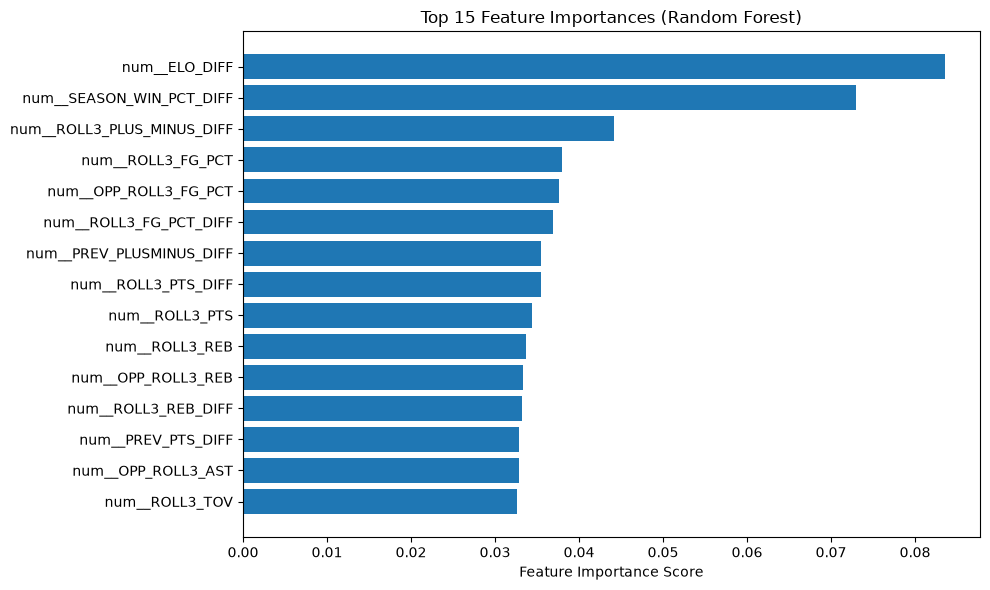

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importances directly from a trained Random Forest model
feature_importances = model.named_steps["classifier"].feature_importances_

# If you used a ColumnTransformer, you can retrieve the expanded column names:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# 2. Create a sorted DataFrame to view top features
importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importances}
).sort_values(by="Importance", ascending=False)

print(importance_df.head(15))

# 3. Optional: Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["Feature"].head(15)[::-1],
    importance_df["Importance"].head(15)[::-1],
)
plt.xlabel("Feature Importance Score")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score
baseline_scores = cross_val_score(model, X_train, y_train, cv=5)
print(baseline_scores.mean(), baseline_scores.std())

0.6338555598012992 0.008821523289573117


In [16]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model, X_train, y_train, cv=tscv)

print(scores)

[0.64495413 0.63899083 0.63073394 0.64449541 0.63761468]


In [17]:
tscv = TimeSeriesSplit(n_splits=5)
for i, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
    model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    acc = model.score(X_train.iloc[test_idx], y_train.iloc[test_idx])
    print(f"Fold {i}: test accuracy = {acc:.3f}, test games from row {test_idx[0]} to {test_idx[-1]}")

Fold 0: test accuracy = 0.645, test games from row 2185 to 4364
Fold 1: test accuracy = 0.639, test games from row 4365 to 6544
Fold 2: test accuracy = 0.631, test games from row 6545 to 8724
Fold 3: test accuracy = 0.644, test games from row 8725 to 10904
Fold 4: test accuracy = 0.638, test games from row 10905 to 13084
